In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [3]:
sns.set_theme(style="whitegrid")

# 1 Data preparation

## 1.1 Load data

In [4]:
df = pd.read_csv("data_final.csv", sep=";")

df.head()

,waktu belajar,cukup atau tidak,kelas,is_cukup
0,80,tidak,D,0
1,175,tidak,D,0
2,105,tidak,C,0
3,100,tidak,C,0
4,210,tidak,D,0


# 1.2 Processing and data cleaning

In [5]:
df["cukup atau tidak"] = df["cukup atau tidak"].astype(str).str.strip().str.lower()

df["is_cukup"] = df["cukup atau tidak"].apply(lambda x: 1 if x == "ya" else 0)

display(df.head())

,waktu belajar,cukup atau tidak,kelas,is_cukup
0,80,tidak,D,0
1,175,tidak,D,0
2,105,tidak,C,0
3,100,tidak,C,0
4,210,tidak,D,0


# 2 Exploratory data analysis

## 2.1 Statistik deskriptif

In [ ]:
# statistik deskriptif waktu belajar
desc_waktu = df["waktu belajar"].describe().round(2).reset_index()

mapping_statistik = {
    "count": "Jumlah data",
    "mean": "Rata-rata",
    "std": "Simpangan baku",
    "min": "Nilai minimum",
    "25%": "Kuartil 1 (Q1)",
    "50%": "Median (Q2)",
    "75%": "Kuartil 3 (Q3)",
    "max": "Nilai maksimum"
}

desc_waktu["index"] = desc_waktu["index"].replace(mapping_statistik)

desc_waktu = desc_waktu.rename(columns={
    "index": "Statistik Deskriptif",
    "waktu belajar": "Nilai Waktu Belajar"
})

print("Statistik Deskriptif Waktu Belajar")
display(desc_waktu)

# distribusi sampel per kelas
dist_kelas = df.groupby("kelas").size().reset_index(name="jumlah_mahasiswa")

dist_kelas = dist_kelas.rename(columns={
    "kelas": "Kelas",
    "jumlah_mahasiswa": "Jumlah Mahasiswa"
})

print("\nDistribusi Sampel per Kelas:")
display(dist_kelas)

# tabulasi silang
tabel_crosstab = pd.crosstab(
    df["kelas"], 
    df["cukup atau tidak"], 
    margins=True, 
    margins_name="Total"
)

tabel_crosstab = tabel_crosstab.rename(columns={
    "tidak": "Tidak", 
    "ya": "Ya"
})

tabel_crosstab.index.name = "Kelas"
tabel_crosstab.columns.name = "Kecukupan Belajar"

print("\nTabulasi Silang antara Kelas dan Kecukupan Belajar")
display(tabel_crosstab)

Statistik Deskriptif Waktu Belajar


,Statistik Deskriptif,Nilai Waktu Belajar
0,Jumlah data,85.00
1,Rata-rata,112.24
2,Simpangan baku,67.37
3,Nilai minimum,0.00
4,Kuartil 1 (Q1),60.00
5,Median (Q2),105.00
6,Kuartil 3 (Q3),155.00
7,Nilai maksimum,355.00



Distribusi Sampel per Kelas:


,Kelas,Jumlah Mahasiswa
0,C,43
1,D,42



Tabulasi Silang (Kelas vs Kecukupan Belajar):


Kecukupan Belajar,Tidak,Ya,Total
Kelas,,,
C,42,1,43
D,40,2,42
Total,82,3,85


## 2.2 Visualisasi grafik

### 2.2.1 Histogram

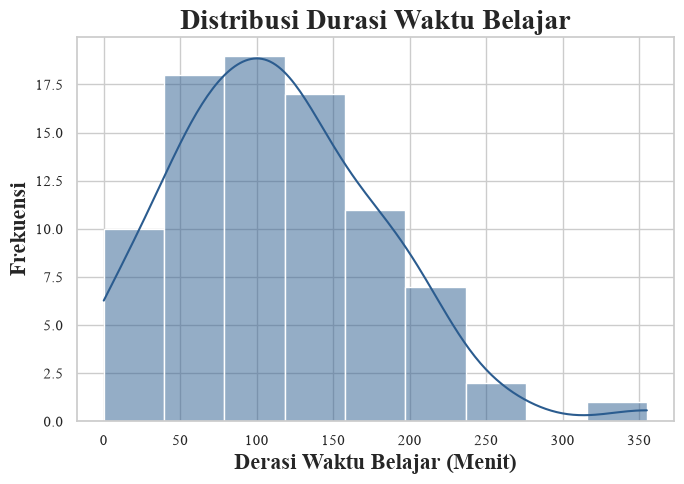

In [7]:
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid", rc={"font.family": "Times New Roman"})

sns.histplot(
    data=df,
    x="waktu belajar",
    kde=True,
    color="#2b5c8f"
)
plt.title("Distribusi Durasi Waktu Belajar", fontsize=20, fontweight="bold")
plt.xlabel("Derasi Waktu Belajar (Menit)", fontsize=16, fontweight="bold")
plt.ylabel("Frekuensi", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### 2.2.2 Pie chart

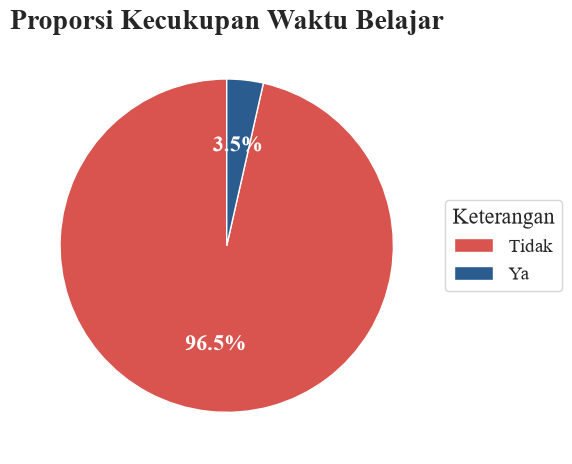

In [8]:
plt.rcParams["font.family"] = "Times New Roman"

counts = df["cukup atau tidak"].value_counts()
color_map = {"ya": "#2b5c8f", "tidak": "#d9534f"}
colors = [color_map[label] for label in counts.index]

wedges, texts, autotexts = plt.pie(
    counts, 
    autopct="%1.1f%%", 
    startangle=90,     
    colors=colors,
    textprops={"fontsize": 16, "color": "white", "weight": "bold"}
)

label_legenda = [label.capitalize() for label in counts.index]

plt.legend(
    wedges, 
    label_legenda,
    title="Keterangan",
    loc="center left",
    bbox_to_anchor=(1, 0.5), 
    fontsize=14,
    title_fontsize=16
)

plt.title("Proporsi Kecukupan Waktu Belajar", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.2.3 Boxplot waktu belajar

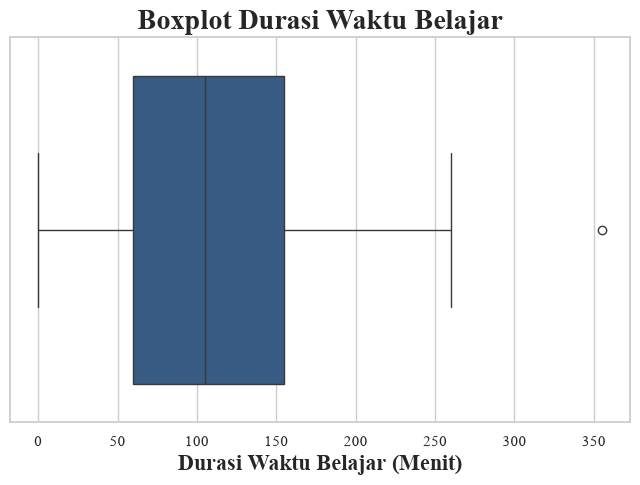

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="waktu belajar", color="#2b5c8f")
plt.title("Boxplot Durasi Waktu Belajar", fontsize=20, fontweight="bold")
plt.xlabel("Durasi Waktu Belajar (Menit)", fontsize=16, fontweight="bold")
plt.show()

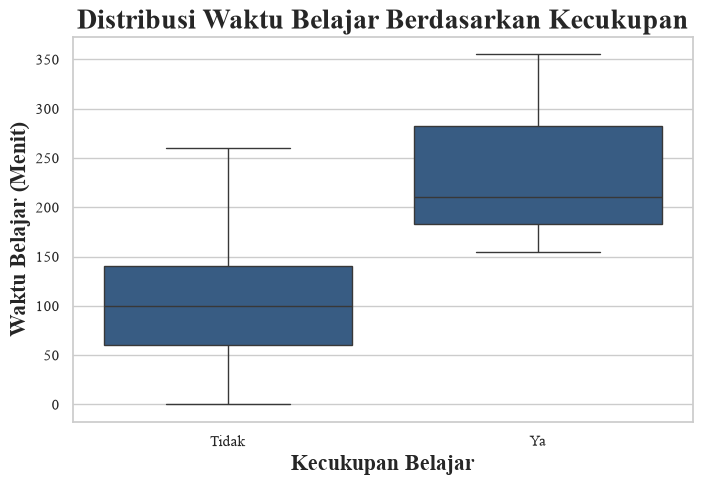

In [70]:
df_plot = df.copy()
df_plot["cukup atau tidak"] = df_plot["cukup atau tidak"].replace({"tidak": "Tidak", "ya": "Ya"})

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x="cukup atau tidak", y="waktu belajar", color="#2b5c8f")

plt.title('Distribusi Waktu Belajar Berdasarkan Kecukupan', fontsize=20, fontweight='bold')
plt.xlabel('Kecukupan Belajar', fontsize=16, fontweight="bold")
plt.ylabel('Waktu Belajar (Menit)', fontsize=16, fontweight="bold")

plt.show()

# 3 Analisis

## 3.1 Estimasi cluster sampling

In [26]:
N = 5
n = df["kelas"].nunique()
f = n / N

cluster_stats = df.groupby("kelas").agg(
    y_i=("waktu belajar", "sum"),
    a_i=("is_cukup", "sum"),
    m_i=("kelas", "count")
).reset_index()

m_bar = cluster_stats["m_i"].mean() # rata-rata ukuran observasi per klaster

print(f"Total klaster populasi (N): {N}")
print(f"Total klaster sampel (n): {n}")
print(f"Rata-rata ukuran klaster (m\u0304): {m_bar}")


tabel_tampil = cluster_stats.rename(columns={
    "kelas": "Kelas",
    "y_i": "Total Waktu Belajar",
    "a_i": "Jumlah Cukup Belajar",
    "m_i": "Jumlah Siswa"
})

display(tabel_tampil)

Total klaster populasi (N): 5
Total klaster sampel (n): 2
Rata-rata ukuran klaster (m̄): 42.5


,Kelas,Total Waktu Belajar,Jumlah Cukup Belajar,Jumlah Siswa
0,C,4985,1,43
1,D,4555,2,42


## 3.2 Estimasi parameter

In [48]:
# estimasi rata-rata waktu belajar
y_bar_est = cluster_stats["y_i"].sum() / cluster_stats["m_i"].sum()
cluster_stats["sq_diff_mean"] = (cluster_stats["y_i"] - y_bar_est * cluster_stats["m_i"])**2
var_y_bar = ((1 - f) / (n * (m_bar**2))) * (cluster_stats["sq_diff_mean"].sum() / (n - 1))
se_y_bar = np.sqrt(var_y_bar)
moe_y_bar = 1.96 * se_y_bar

# estimasi proporsi kecukupan belajar
p_est = cluster_stats["a_i"].sum() / cluster_stats["m_i"].sum()
cluster_stats["sq_diff_prop"] = (cluster_stats["a_i"] - p_est * cluster_stats["m_i"])**2
var_p = ((1 - f) / (n * (m_bar**2))) * (cluster_stats["sq_diff_prop"].sum() / (n - 1))
se_p = np.sqrt(var_p)
moe_p = 1.96 * se_p

# output
print("Hasil Estimasi Parameter")

print("\n1. Estimasi rata-rata waktu belajar:")
print(f"   Estimasi titik (\u0079\u0304): {y_bar_est:.2f} menit/hari")
print(f"   Standard error (SE): {se_y_bar:.2f}")
print(f"   Margin of error (95%): {moe_y_bar:.2f}")
print(f"   Interval kepercayaan: [{y_bar_est - moe_y_bar:.2f}, {y_bar_est + moe_y_bar:.2f}] menit")

print("\n2. Estimasi proporsi kecukupan belajar:")
print(f"   Estimasi titik (p\u0302): {p_est:.4f} ({p_est*100:.2f}%)")
print(f"   Standard error (SE): {se_p:.4f}")
print(f"   Margin of error (95%): {moe_p:.4f} ({moe_p*100:.2f}%)")
print(f"   Interval kepercayaan: [{(p_est - moe_p)*100:.2f}%, {(p_est + moe_p)*100:.2f}%]")

Hasil Estimasi Parameter

1. Estimasi rata-rata waktu belajar:
   Estimasi titik (ȳ): 112.24 menit/hari
   Standard error (SE): 2.90
   Margin of error (95%): 5.68
   Interval kepercayaan: [106.56, 117.91] menit

2. Estimasi proporsi kecukupan belajar:
   Estimasi titik (p̂): 0.0353 (3.53%)
   Standard error (SE): 0.0094
   Margin of error (95%): 0.0185 (1.85%)
   Interval kepercayaan: [1.68%, 5.38%]


In [49]:
data_tabel = {
    "Parameter Statistik": [
        "Estimasi Titik", 
        "Standard Error (SE)", 
        "Margin of Error (95%)", 
        "Interval Kepercayaan"
    ],
    "Rata-rata Waktu Belajar": [
        f"{y_bar_est:.2f} menit",
        f"{se_y_bar:.2f}",
        f"{moe_y_bar:.2f}",
        f"[{y_bar_est - moe_y_bar:.2f}, {y_bar_est + moe_y_bar:.2f}] menit"
    ],
    "Proporsi Kecukupan Belajar": [
        f"{p_est:.4f} ({p_est*100:.2f}%)",
        f"{se_p:.4f}",
        f"{moe_p:.4f} ({moe_p*100:.2f}%)",
        f"[{(p_est - moe_p)*100:.2f}%, {(p_est + moe_p)*100:.2f}%]"
    ]
}

df_hasil = pd.DataFrame(data_tabel)
df_hasil.set_index("Parameter Statistik", inplace=True)

print("Tabel Hasil Estimasi Parameter\n")
display(df_hasil)

Tabel Hasil Estimasi Parameter



,Rata-rata Waktu Belajar,Proporsi Kecukupan Belajar
Parameter Statistik,,
Estimasi Titik,112.24 menit,0.0353 (3.53%)
Standard Error (SE),2.90,0.0094
Margin of Error (95%),5.68,0.0185 (1.85%)
Interval Kepercayaan,"[106.56, 117.91] menit","[1.68%, 5.38%]"
